Scikit-learn : precision_recall_curve and average_precision_score

The average precision score for seed6mer is 0.4809127394275979
The average precision score for seed7mer is 0.4818074148377174
The average precision score for seed8mer is 0.4701463257461219


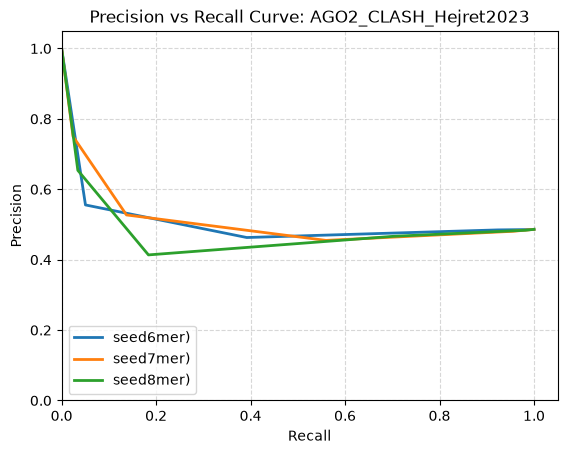

The average precision score for seed6mer is 0.540353506612013
The average precision score for seed7mer is 0.5526893451678839
The average precision score for seed8mer is 0.5400447281861576


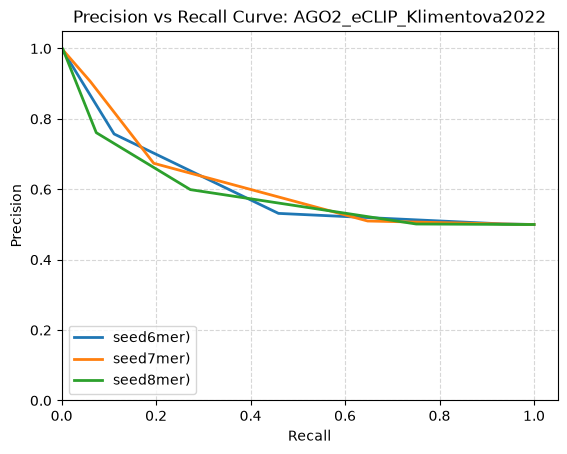

The average precision score for seed6mer is 0.5061659338922128
The average precision score for seed7mer is 0.5121080416755291
The average precision score for seed8mer is 0.5052503552208341


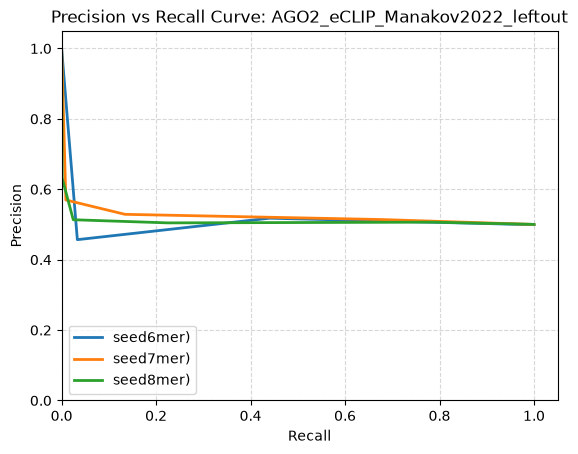

The average precision score for seed6mer is 0.5174320851663131
The average precision score for seed7mer is 0.5193020335874464
The average precision score for seed8mer is 0.5183277798048768


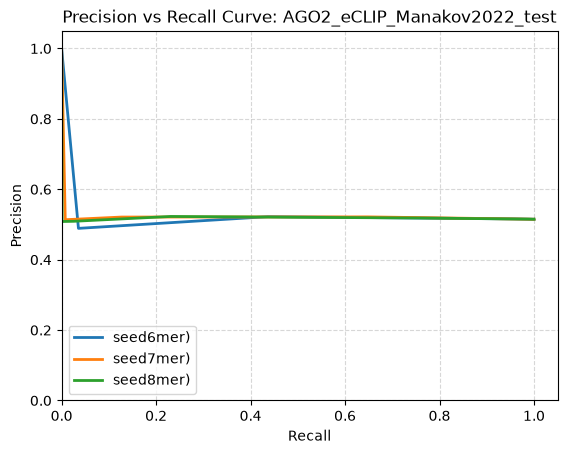

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

df1=pd.read_csv("AGO2_CLASH_Hejret2023_alignment_score.tsv", sep="\t")[["gene", "noncodingRNA", "label", "seed6mer", "seed7mer", "seed8mer"]]
df2=pd.read_csv("AGO2_eCLIP_Klimentova2022_alignment_score.tsv", sep="\t")[["gene", "noncodingRNA", "label", "seed6mer", "seed7mer", "seed8mer"]]
df3=pd.read_csv("AGO2_eCLIP_Manakov2022_leftout_alignment_score.tsv", sep="\t")[["gene", "noncodingRNA", "label", "seed6mer", "seed7mer", "seed8mer"]]
df4=pd.read_csv("AGO2_eCLIP_Manakov2022_test_alignment_score.tsv", sep="\t")[["gene", "noncodingRNA", "label", "seed6mer", "seed7mer", "seed8mer"]]
datasets = {"AGO2_CLASH_Hejret2023": df1,
    "AGO2_eCLIP_Klimentova2022": df2,
    "AGO2_eCLIP_Manakov2022_leftout": df3,
    "AGO2_eCLIP_Manakov2022_test": df4,}

seed_models = ['seed6mer', 'seed7mer', 'seed8mer']

def evaluate_precision(df, model):
    y_true = np.array(df['label'])
    y_scores = np.array(df[model])
    ap = average_precision_score(y_true, y_scores)
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    return precision, recall, thresholds, ap

results=[]
for name, df in datasets.items():
   for model in seed_models:
       precision, recall, thresholds, ap = evaluate_precision(df, model)
       results.append({"dataset": name, "model": model, "precision": precision, "recall": recall,"ap": ap})

for name in datasets:
    plt.figure()
    for r in results:
        if r['dataset'] == name:
            plt.plot(r['recall'], r['precision'], label=f"{r['model']})", linewidth=2,)
            print(f'The average precision score for {r["model"]} is {r["ap"]}')
            
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision vs Recall Curve: {name}", fontsize=12)
    plt.xlim([0.0, 1.05])
    plt.ylim([0.0, 1.05])
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(loc="lower left")
    plt.show()               